In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cơ bản cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# 1. Đọc dữ liệu
df = pd.read_csv('../data/vietnam_housing_dataset.csv') # Đổi lại tên file cho khớp với file của bạn

# 2. Xem 5 dòng đầu tiên để có cái nhìn trực quan
display(df.head())

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 2.8 MB


In [3]:
df.isnull().sum()

Address                  0
Area                     0
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bedrooms              5162
Bathrooms             7074
Legal status          4506
Furniture state      14119
Price                    0
dtype: int64

1. Xóa cột (Drop Columns) - Dành cho tỷ lệ thiếu > 50%
Ngoài các cột Address, Area và Price ra, các cột khác đều có những khoảng bị thiếu dữ liệu, Balcony direction (thiếu 24.983) và House direction (thiếu 21.239). Số lượng khuyết quá lớn, nếu cố tình điền bừa sẽ làm sai lệch mô hình. Các cột như Access Road (13.297) hay Furniture state (14.119) cũng nên được cân nhắc.

2. Điền khuyết (Imputation) - Dành cho dữ liệu thiếu < 20-30%
Các cột như Floors (3603), Bedrooms (5162), Bathrooms (7074) là những đặc trưng cực kỳ quan trọng quyết định giá nhà. Thay vì xóa cột hay xóa dòng (gây lãng phí dữ liệu), chúng ta sẽ điền vào chỗ trống. Ví dụ, số lượng (phòng, tầng): Điền trung vị (median). (Ví dụ: Đa số nhà có 2 phòng ngủ, ta điền số 2 vào các ô bị trống). Còn đối với Legal status, các giá trị trống sẽ được thay bằng 'Sale contract' vì với các bất động sản bị bỏ trống thông tin thường có nguy cơ là do buôn bán sang tay.

3. Xóa dòng (Drop Rows) - Dành cho tỷ lệ thiếu rất nhỏ
Nếu sau khi xử lý mà vẫn còn rải rác vài chục hoặc vài trăm dòng bị thiếu thông tin ở một số cột, bạn có thể dùng lệnh df.dropna() để xóa các dòng đó đi. Với một dataset hàng chục ngàn dòng, việc mất đi một lượng nhỏ không đáng kể.

In [8]:
df.describe()

,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Price
count,30229.000000,18665.000000,16932.000000,26626.000000,25067.000000,23155.000000,30229.000000
mean,68.498741,5.361692,7.853800,3.410426,3.511030,3.346837,5.872078
std,48.069835,4.346174,7.451313,1.328897,1.309116,1.400181,2.211877
min,3.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,40.000000,4.000000,4.000000,2.000000,3.000000,2.000000,4.200000
50%,56.000000,4.500000,6.000000,3.000000,3.000000,3.000000,5.900000
75%,80.000000,5.000000,10.000000,4.000000,4.000000,4.000000,7.500000
max,595.000000,77.000000,85.000000,10.000000,9.000000,9.000000,11.500000


Cột Area có một số giá trị bất thường khiến cho nó có biên độ rất lớn, có thể ảnh hưởng tới việc tính toán

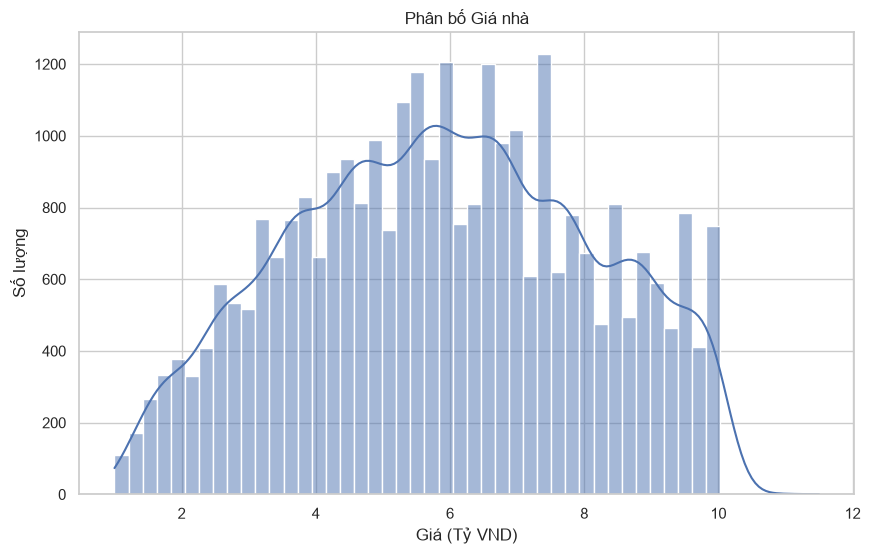

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Phân bố Giá nhà')
plt.xlabel('Giá (Tỷ VND)')
plt.ylabel('Số lượng')
plt.show()

Hình dáng phân bố: Biểu đồ không bị lệch phải quá gắt, mà có xu hướng phân bố khá đồng đều trong khoảng từ 1 đến 10 tỷ VNĐ. Các mức giá tập trung đông đảo nhất (đỉnh biểu đồ) rơi vào khoảng 5.5 đến 7.5 tỷ.

Ý nghĩa với mô hình: Vì dữ liệu cao nhất bị giới hạn ở mức 10 tỷ, mô hình Linear Regression mà chúng ta sắp xây dựng sẽ chỉ hoạt động chính xác cho phân khúc nhà ở bình dân và trung cấp. Mô hình sẽ không có khả năng dự đoán đúng giá cho các căn biệt thự hoặc nhà phố siêu ngạch (ví dụ 20-50 tỷ).

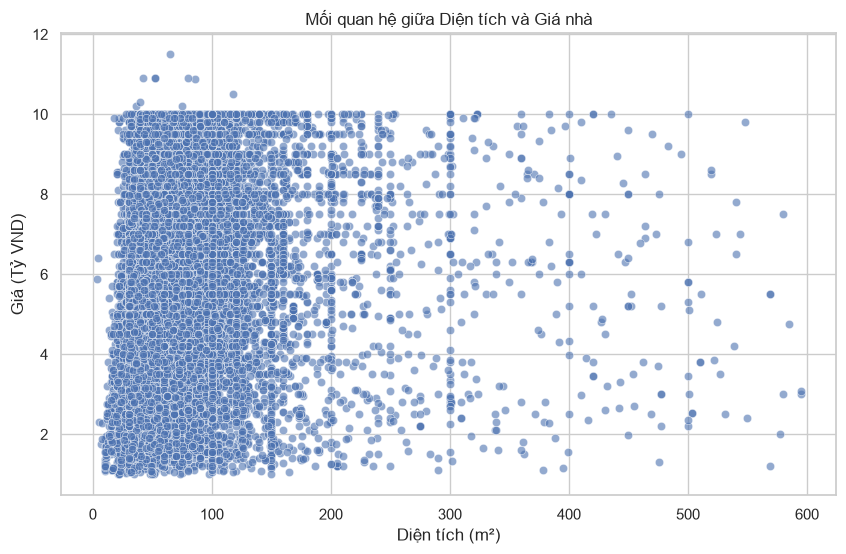

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Area', y='Price', data=df, alpha=0.6)
plt.title('Mối quan hệ giữa Diện tích và Giá nhà')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Giá (Tỷ VND)')
plt.show()

Mật độ dữ liệu: Phần lớn các giao dịch tập trung thành một khối đặc ở mức diện tích từ 30m² đến 150m².

Mối quan hệ Tuyến tính: Chúng ta không thấy một đường chéo đi lên mỏng và sắc nét, mà là một đám mây điểm phân tán rộng. Một căn nhà 50m² có thể có giá chỉ 2 tỷ, nhưng cũng có thể lên tới trần 10 tỷ.

Ý nghĩa với mô hình: Điều này phản ánh cực kỳ chính xác bản chất thị trường bất động sản: Diện tích không phải là yếu tố duy nhất quyết định giá. Giá nhà còn phụ thuộc rất mạnh vào các yếu tố khác như Vị trí (Quận/Huyện), hoặc Tình trạng pháp lý. Việc sử dụng Linear Regression đa biến (Multiple Linear Regression) kết hợp nhiều đặc trưng thay vì chỉ dùng mỗi diện tích là một quyết định hoàn toàn bắt buộc.